# Sampling

We cannot record the amplitude of a sound at every possible point in time. So we will have to take *samples* of the sound at a regular rate. This rate is called the **sampling rate** or **sampling frequency**, abbreviated $f_s$ and is measured in Hertz (Hz). One Hertz means something happens once per second, two Hertz is two times per second, etc. So if we sample a sound at a rate of 100 Hz, we are taking 100 samples per second. The **sampling period** $T$ is the length of time between two samples, and is the reciprocal of the sampling rate $$T = 1/f_s$$ For a 100 Hz sampling rate, the period is 0.01 seconds ($T=\frac{1}{100}=0.01$).

In [1]:
def sampling_period(f_s):
    return 1/f_s

SAMPLE_RATE = 100
print(f"The sample rate is {SAMPLE_RATE} Hz")
print(f"The sampling period is {sampling_period(SAMPLE_RATE)} s.")

The sample rate is 100 Hz
The sampling period is 0.01 s.


Let's think about sampling a sine wave. A sine wave has this shape:

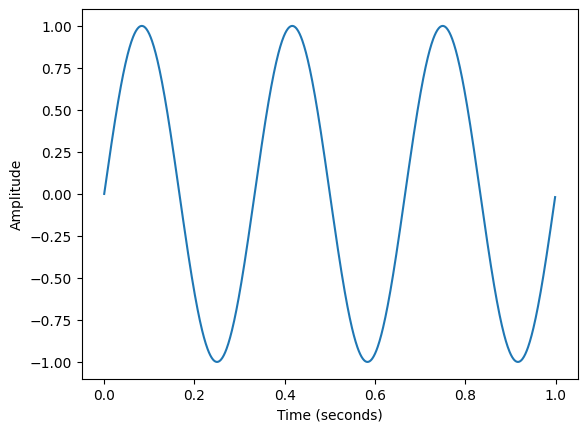

In [6]:
import matplotlib.pyplot as plt
import numpy as np

SAMPLE_RATE = 1000
sig1_frequency = 3
sig1_phase = 0  # range: [0, 2pi)
sig1_length = sig1_frequency * 2 * np.pi
sig1 = np.sin(np.arange(sig1_phase, sig1_length + sig1_phase, sig1_length / SAMPLE_RATE))
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot([i / SAMPLE_RATE for i in range(SAMPLE_RATE)], sig1)

Since the shape of a sine wave follows a curve, we'd have to take *infinitely* many samples to capture the shape perfecly. If we don't do that, we'll end up with something like this:

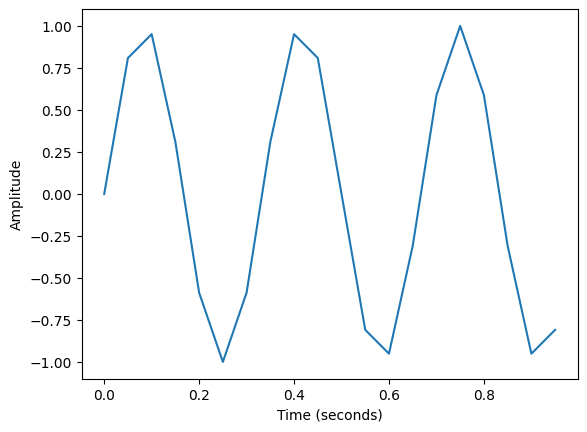

In [ ]:
SAMPLE_RATE = 20
sig1_frequency = 3
sig1_phase = 0  # range: [0, 2pi)
sig1_length = sig1_frequency * 2 * np.pi
sig1 = np.sin(np.arange(sig1_phase, sig1_length + sig1_phase, sig1_length / SAMPLE_RATE))
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot([i / SAMPLE_RATE for i in range(SAMPLE_RATE)], sig1)

That doesn't look much like a sine wave, does it? Fortunately, it turns out that this is perfectly OK. A digital-to-analog converter (DAC) runs its output through a low-pass filter. This gets rid of the sharp points and smooths out the signal.

Hmmm. Maybe we only need two sample the sine wave twice: once for the peak and once for the trough. This lines up with the famous Nyqist/Shannon sampling theorem says that **for a given sampling rate $f_s$, we can only capture frequencies in the range $[0, f_s/2]$ without aliasing** (i.e. we need at least two samples per sine wave).

## Sine Waves Close to the Nyquist Barrier
What might it look like if we try to record a sine wave that's *exactly* at the Nyquist frequency? Let's say we have a sampling frequency of 16 Hz, and a sine wave at 8 Hz.

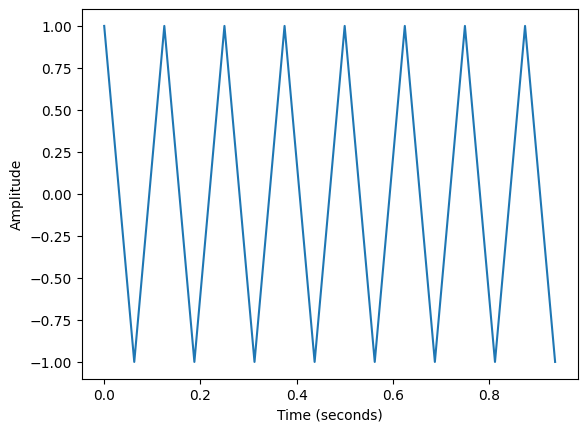

In [9]:
SAMPLE_RATE = 16
sig1_frequency = 8
sig1_phase = 0  # range: [0, 2pi)
sig1_length = sig1_frequency * 2 * np.pi
sig1 = np.cos(np.arange(sig1_phase, sig1_length + sig1_phase, sig1_length / SAMPLE_RATE))
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot([i / SAMPLE_RATE for i in range(SAMPLE_RATE)], sig1)

Ok, this looks like a triangle wave. It is, but the low-pass filter in the DAC will smooth it out. So this tends to confirm the Nyquist/Shannon rule that we can represent sine waves with frequencies up to half the sampling rate.

What happens, though, if the sine wave isn't exactly in phase with the digital sampling mechanism?

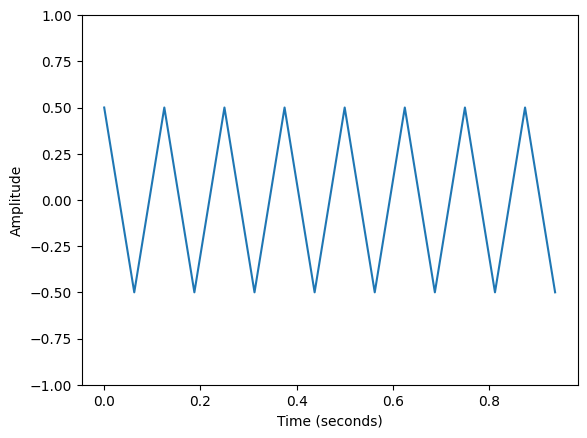

In [11]:
SAMPLE_RATE = 16
sig1_frequency = 8
sig1_phase = np.pi / 3  # range: [0, 2pi)
sig1_length = sig1_frequency * 2 * np.pi
sig1 = np.cos(np.arange(sig1_phase, sig1_length + sig1_phase, sig1_length / SAMPLE_RATE))
plt.ylim(-1, 1)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot([i / SAMPLE_RATE for i in range(SAMPLE_RATE)], sig1)

Whoops! It turns out that if we have a sine wave at the Nyquist frequency, and we aren't sampling exactly at the right times, we can't record the full amplitude of the signal properly! 

Let's explore another problem that we encounter close to the Nyquist frequency. What happens if we're *really close* to the Nyquist frequency? In this example, we have a sample rate of 64 Hz, and we're sampling a 30 Hz sine wave. $\frac{30}{64} \approx 0.47$ which is close to the Nyquist barrier.

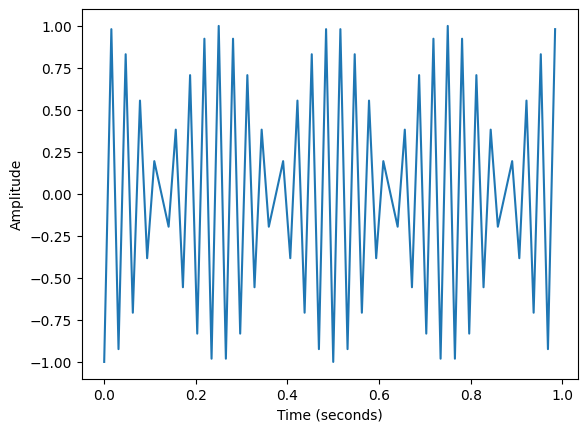

In [12]:
import matplotlib.pyplot as plt
import numpy as np

SAMPLE_RATE = 64
sig3_frequency = 30
sig3_phase = np.pi  # range: [0, 2pi)
sig3_length = sig3_frequency * 2 * np.pi
sig3 = np.cos(np.arange(sig3_phase, sig3_length + sig3_phase, sig3_length / SAMPLE_RATE))
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot([i / SAMPLE_RATE for i in range(SAMPLE_RATE)], sig3)

Oh no! Suddenly we have amplitude modulation in our signal.

Why? We can intuitively realize that if this wave is close to Nyquist, most of the periods will be represented by 2 samples. Every once in a while, we'll get a period that's represented by 3 samples. As the sampling points drift across the wave, sometimes we sample it close to full amplitude, and other times we do not. Try experimenting with different frequencies, and see what happens.

## Aliasing

When we record a signal with a frequency above the Nyquist barrier, then play back what we recorded, we'll hear a different frequency than we expected. This is because of *aliasing*. Basically, it means that a frequency *inside* the Nyquist barrier can represent infinitely many frequencies outside the Nyquist barrier, according to the formula $$f=f+nf_s$$ where $n \in \mathbb{Z}$.

Let's plot a test signal, using a sampling rate of 16 Hz, and a frequency of 2 Hz. We'll plot one second of the sound.

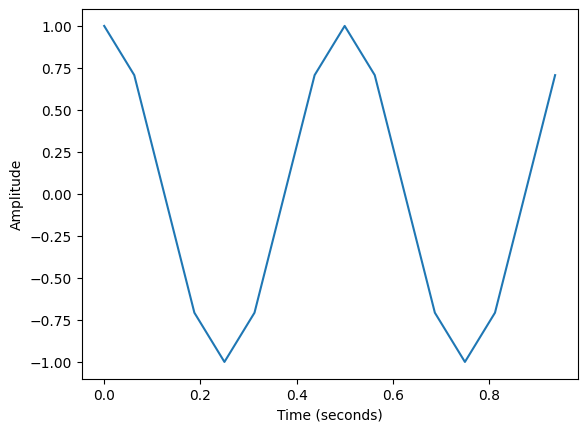

In [ ]:
SAMPLE_RATE = 16
sig1_frequency = 2
sig1_phase = 0  # range: [0, 2pi)
sig1_length = sig1_frequency * 2 * np.pi
sig1 = np.cos(np.arange(sig1_phase, sig1_length + sig1_phase, sig1_length / SAMPLE_RATE))
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot([i / SAMPLE_RATE for i in range(SAMPLE_RATE)], sig1)

Since the sampling rate is 16 Hz, we are taking 16 samples per second. We've captured our 2 Hz signal accurately, even though the reconstruction looks jagged. What happens if we try to plot a signal with a frequency of 2 + 16 = 18 Hz?

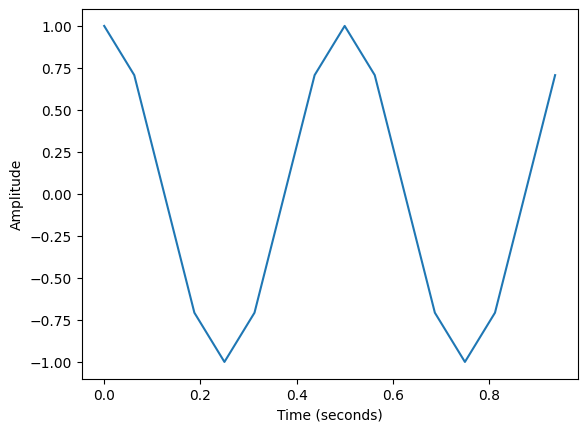

In [19]:
sig2_frequency = 18
sig2_phase = 0  # range: [0, 2pi)
sig2_length = sig2_frequency * 2 * np.pi
sig2 = np.cos(np.arange(sig2_phase, sig2_length + sig2_phase, sig2_length / SAMPLE_RATE))
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.plot([i / SAMPLE_RATE for i in range(SAMPLE_RATE)], sig2)

We get the same reconstructed signal! The frequency 2 Hz is acting as an alias for the frequencies ..., -14, 2, 18, 34, 50, ... Hz. Try changing the frequency in the code block above to one of these other frequencies.

## Bottom Line
There are several observations that we can make now:
- It's actually best to stay reasonably well below the Nyquist barrier to avoid problems. That said, in music we don't rely on super high frequencies close to 20 kHz. So a sampling rate of 44.1 kHz is actually ok.
- Even though there are jagged edges in our reconstructed signal, we don't have to worry about that because the analog low-pass filter in the DAC will smooth them out.
- If we try to record a sine wave above the Nyquist frequency, it will *alias* to (be represented by) a signal with a frequency in the range $[0, f_s]$. While aliasing can be useful in signal processing, we generally don't like it in audio.

